In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import qmc
import os, warnings

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
np.random.seed(42)


def softplus(x):
    """sigma_mc: convex and monotone non-decreasing  =>  log(1 + e^x)"""
    return np.log1p(np.exp(np.clip(x, -500, 30)))

def d_softplus(x):
    """First derivative of softplus = sigmoid(x)"""
    return 1.0 / (1.0 + np.exp(np.clip(-x, -500, 500)))

def sigmoid(x):
    """sigma_m = sigma_a: monotone non-decreasing  =>  1/(1+e^{-x})"""
    return 1.0 / (1.0 + np.exp(np.clip(-x, -500, 500)))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1.0 - s)


def lhs_sample(n, dim, lo, hi, seed=0):
    sampler = qmc.LatinHypercube(d=dim, seed=seed)
    raw = sampler.random(n=n)
    return qmc.scale(raw, lo, hi)


def generate_additive(n_train=500, n_test=5000):
    """
    Eq. 12:  f = exp(-0.5x) + log(1+exp(0.4y)) + tanh(t) + sin(z) - 0.4
    Train domain [0,4]^4,  Test domain [0,6]^4
    Structural properties:
        x => convex
        y => convex AND monotone non-decreasing
        t => monotone non-decreasing
        z => arbitrary
    """
    def f(X):
        x, y, t, z = X[:,0], X[:,1], X[:,2], X[:,3]
        return (np.exp(-0.5*x) + np.log1p(np.exp(0.4*y))
                + np.tanh(t) + np.sin(z) - 0.4).reshape(-1,1)

    X_tr = lhs_sample(n_train, 4, 0.0, 4.0, seed=1)
    X_te = lhs_sample(n_test,  4, 0.0, 6.0, seed=2)
    return X_tr, f(X_tr), X_te, f(X_te), f


def generate_multiplicative(n_train=500, n_test=5000):
    """
    Eqs. 13-14:  g = fx*fy*ft*fz
        fx=exp(-0.3x),  fy=(0.15y)^2,  ft=tanh(0.3t),  fz=0.2sin(0.5z+2)+0.5
    Train domain [0,4]^4,  Test domain [0,10]^4
    """
    def g(X):
        x, y, t, z = X[:,0], X[:,1], X[:,2], X[:,3]
        fx = np.exp(-0.3*x)
        fy = (0.15*y)**2
        ft = np.tanh(0.3*t)
        fz = 0.2*np.sin(0.5*z + 2) + 0.5
        return (fx * fy * ft * fz).reshape(-1,1)

    X_tr = lhs_sample(n_train, 4, 0.0,  4.0, seed=3)
    X_te = lhs_sample(n_test,  4, 0.0, 10.0, seed=4)
    return X_tr, g(X_tr), X_te, g(X_te), g


class ISNN1:

    def __init__(self, hidden_dim=10, hidden_layers=2, rng=None):
        if rng is None:
            rng = np.random.default_rng(42)
        nh, nl = hidden_dim, hidden_layers

        sp = lambda r,c: rng.uniform(0.0, 0.1, (r,c))   # small positive
        sr = lambda r,c: rng.uniform(-0.1, 0.1, (r,c))  # small random
        zr = lambda n: np.zeros(n)

        # y-branch  (W NON-NEG, sigma_mc)
        self.Wyy = [sp(nh,1)] + [sp(nh,nh) for _ in range(nl-1)]
        self.bby = [zr(nh) for _ in range(nl)]

        # z-branch  (W free, sigma_a = sigmoid)
        self.Wzz = [sr(nh,1)] + [sr(nh,nh) for _ in range(nl-1)]
        self.bbz = [zr(nh) for _ in range(nl)]

        # t-branch  (W NON-NEG, sigma_m = sigmoid)
        self.Wtt = [sp(nh,1)] + [sp(nh,nh) for _ in range(nl-1)]
        self.bbt = [zr(nh) for _ in range(nl)]

        # x-branch layer-0 coupling weights
        self.Wxx0 = sr(nh, 1)    # x0 -> x1, FREE (allows negative stresses)
        self.Wxy  = sp(nh, nh)   # y_out -> x, NON-NEG
        self.Wxz  = sr(nh, nh)   # z_out -> x, free
        self.Wxt  = sp(nh, nh)   # t_out -> x, NON-NEG
        self.bbx0 = zr(nh)

        # x-branch hidden layers h=1..Hx-1  (W NON-NEG)
        self.Wxx  = [sp(nh,nh) for _ in range(nl-1)]
        self.bbx  = [zr(nh) for _ in range(nl-1)]

        # output layer
        self.Wout = sp(1, nh)    # NON-NEG
        self.bout = zr(1)

    def enforce_constraints(self):
        """Clamp all weights that must be non-negative."""
        for W in self.Wyy: W[:] = np.maximum(W, 0)
        for W in self.Wtt: W[:] = np.maximum(W, 0)
        self.Wxy[:] = np.maximum(self.Wxy, 0)
        self.Wxt[:] = np.maximum(self.Wxt, 0)
        for W in self.Wxx: W[:] = np.maximum(W, 0)
        self.Wout[:] = np.maximum(self.Wout, 0)

    def __call__(self, x0, y0, t0, z0):
        """PyTorch-style call."""
        out, _ = self.forward(x0, y0, t0, z0)
        return out

    # ------------------------------------------------------------------
    def forward(self, x0, y0, t0, z0):
        """
        Forward pass.
        x0,y0,t0,z0 : (N,1) arrays
        Returns (output (N,1), cache dict for backprop)
        """
        cache = {'x0':x0, 'y0':y0, 't0':t0, 'z0':z0}

        # --- y-branch ---
        yh = y0
        y_pre, y_act = [], [y0]
        for h in range(len(self.Wyy)):
            pre = yh @ self.Wyy[h].T + self.bby[h]
            yh  = softplus(pre)
            y_pre.append(pre); y_act.append(yh)
        cache['y_pre'], cache['y_act'] = y_pre, y_act

        # --- z-branch ---
        zh = z0
        z_pre, z_act = [], [z0]
        for h in range(len(self.Wzz)):
            pre = zh @ self.Wzz[h].T + self.bbz[h]
            zh  = sigmoid(pre)
            z_pre.append(pre); z_act.append(zh)
        cache['z_pre'], cache['z_act'] = z_pre, z_act

        # --- t-branch ---
        th = t0
        t_pre, t_act = [], [t0]
        for h in range(len(self.Wtt)):
            pre = th @ self.Wtt[h].T + self.bbt[h]
            th  = sigmoid(pre)
            t_pre.append(pre); t_act.append(th)
        cache['t_pre'], cache['t_act'] = t_pre, t_act

        # --- x-branch layer 0 ---
        yH = y_act[-1]; zH = z_act[-1]; tH = t_act[-1]
        pre0 = (x0 @ self.Wxx0.T + yH @ self.Wxy.T
                + zH @ self.Wxz.T + tH @ self.Wxt.T + self.bbx0)
        xh = softplus(pre0)
        x_pre, x_act = [pre0], [xh]

        # --- x-branch hidden layers ---
        for h in range(len(self.Wxx)):
            pre = xh @ self.Wxx[h].T + self.bbx[h]
            xh  = softplus(pre)
            x_pre.append(pre); x_act.append(xh)
        cache['x_pre'], cache['x_act'] = x_pre, x_act

        # --- output (linear) ---
        out = xh @ self.Wout.T + self.bout
        return out, cache

    # ------------------------------------------------------------------
    def backward(self, dL_dout, cache):
        """
        Manual Backpropagation.

        Implements the chain rule layer-by-layer following slide 194:

          delta(L)   = dL/d(pre_L) = (upstream gradient) o sigma'(pre_L)
          dL/dW(h)   = delta(h)^T  @  act(h-1)
          dL/db(h)   = sum(delta(h), axis=0)
          upstream_h = delta(h) @ W(h)

        For the output layer (linear activation): delta = dL_dout.
        For hidden layers (softplus): delta = upstream o softplus'(pre).
        """
        grads = {}

        # === Output layer (linear) ===
        xH = cache['x_act'][-1]
        grads['Wout'] = dL_dout.T @ xH          # (1, nh)
        grads['bout'] = dL_dout.sum(axis=0)
        dL_dxH = dL_dout @ self.Wout             # (N, nh)

        # === x-branch hidden layers (h = Hx-1 .. 1) ===
        grads_Wxx = []; grads_bbx = []
        dL_dxh = dL_dxH
        for h in reversed(range(len(self.Wxx))):
            pre   = cache['x_pre'][h+1]
            delta = dL_dxh * d_softplus(pre)     # delta_h = upstream o sigma'
            grads_Wxx.insert(0, delta.T @ cache['x_act'][h])
            grads_bbx.insert(0, delta.sum(axis=0))
            dL_dxh = delta @ self.Wxx[h]         # propagate upstream: delta @ W
        grads['Wxx'] = grads_Wxx
        grads['bbx'] = grads_bbx

        # === x-branch layer 0 ===
        delta0 = dL_dxh * d_softplus(cache['x_pre'][0])
        grads['Wxx0'] = delta0.T @ cache['x0']
        grads['Wxy']  = delta0.T @ cache['y_act'][-1]
        grads['Wxz']  = delta0.T @ cache['z_act'][-1]
        grads['Wxt']  = delta0.T @ cache['t_act'][-1]
        grads['bbx0'] = delta0.sum(axis=0)

        # upstream into sub-branches
        dL_dyH = delta0 @ self.Wxy
        dL_dzH = delta0 @ self.Wxz
        dL_dtH = delta0 @ self.Wxt

        # === y-branch backward ===
        grads_Wyy = []; grads_bby = []
        dL_dy = dL_dyH
        for h in reversed(range(len(self.Wyy))):
            delta = dL_dy * d_softplus(cache['y_pre'][h])
            grads_Wyy.insert(0, delta.T @ cache['y_act'][h])
            grads_bby.insert(0, delta.sum(axis=0))
            dL_dy = delta @ self.Wyy[h]
        grads['Wyy'] = grads_Wyy; grads['bby'] = grads_bby

        # === z-branch backward ===
        grads_Wzz = []; grads_bbz = []
        dL_dz = dL_dzH
        for h in reversed(range(len(self.Wzz))):
            delta = dL_dz * d_sigmoid(cache['z_pre'][h])
            grads_Wzz.insert(0, delta.T @ cache['z_act'][h])
            grads_bbz.insert(0, delta.sum(axis=0))
            dL_dz = delta @ self.Wzz[h]
        grads['Wzz'] = grads_Wzz; grads['bbz'] = grads_bbz

        # === t-branch backward ===
        grads_Wtt = []; grads_bbt = []
        dL_dt = dL_dtH
        for h in reversed(range(len(self.Wtt))):
            delta = dL_dt * d_sigmoid(cache['t_pre'][h])
            grads_Wtt.insert(0, delta.T @ cache['t_act'][h])
            grads_bbt.insert(0, delta.sum(axis=0))
            dL_dt = delta @ self.Wtt[h]
        grads['Wtt'] = grads_Wtt; grads['bbt'] = grads_bbt

        return grads


class ISNN2:
    """Input Specific Neural Network - Type 2 (shared depth, skip connections)."""
    def __init__(self, hidden_dim=15, hidden_layers=1, rng=None):
        if rng is None:
            rng = np.random.default_rng(42)
        nh, H = hidden_dim, hidden_layers

        sp = lambda r,c: rng.uniform(0.0, 0.1, (r,c))
        sr = lambda r,c: rng.uniform(-0.1, 0.1, (r,c))
        zr = lambda n: np.zeros(n)

        # sub-branches: H layers total (h=0..H-1)
        nb = max(H, 1)

        # y-branch (NON-NEG, sigma_mc)
        self.Wyy = [sp(nh,1)] + [sp(nh,nh) for _ in range(nb-1)]
        self.bby = [zr(nh) for _ in range(nb)]

        # z-branch (free, sigmoid)
        self.Wzz = [sr(nh,1)] + [sr(nh,nh) for _ in range(nb-1)]
        self.bbz = [zr(nh) for _ in range(nb)]

        # t-branch (NON-NEG, sigmoid)
        self.Wtt = [sp(nh,1)] + [sp(nh,nh) for _ in range(nb-1)]
        self.bbt = [zr(nh) for _ in range(nb)]

        # x-branch layer 0: processes raw inputs
        self.Wxx_0  = sr(nh, 1)   # x0 input, free
        self.Wxy_0  = sp(nh, 1)   # y0 input, NON-NEG
        self.Wxz_0  = sr(nh, 1)   # z0 input, free
        self.Wxt_0  = sp(nh, 1)   # t0 input, NON-NEG
        self.bbx0   = zr(nh)

        # x-branch layers h=1..H-1: skip connections
        nx = H - 1
        self.Wxx_h  = [sp(nh, nh) for _ in range(nx)]  # xh, NON-NEG
        self.Wxx0_h = [sr(nh, 1)  for _ in range(nx)]  # x0 skip, free
        self.Wxy_h  = [sp(nh, nh) for _ in range(nx)]  # yh, NON-NEG
        self.Wxz_h  = [sr(nh, nh) for _ in range(nx)]  # zh, free
        self.Wxt_h  = [sp(nh, nh) for _ in range(nx)]  # th, NON-NEG
        self.bbxh   = [zr(nh) for _ in range(nx)]

        # output
        self.Wout = sp(1, nh)
        self.bout = zr(1)

    def enforce_constraints(self):
        for W in self.Wyy: W[:] = np.maximum(W, 0)
        for W in self.Wtt: W[:] = np.maximum(W, 0)
        self.Wxy_0[:] = np.maximum(self.Wxy_0, 0)
        self.Wxt_0[:] = np.maximum(self.Wxt_0, 0)
        for W in self.Wxx_h: W[:] = np.maximum(W, 0)
        for W in self.Wxy_h: W[:] = np.maximum(W, 0)
        for W in self.Wxt_h: W[:] = np.maximum(W, 0)
        self.Wout[:] = np.maximum(self.Wout, 0)

    def __call__(self, x0, y0, t0, z0):
        out, _ = self.forward(x0, y0, t0, z0)
        return out

    def forward(self, x0, y0, t0, z0):
        cache = {'x0':x0, 'y0':y0, 't0':t0, 'z0':z0}

        # --- y-branch ---
        yh = y0
        y_pre, y_act = [], [y0]
        for h in range(len(self.Wyy)):
            pre = yh @ self.Wyy[h].T + self.bby[h]
            yh  = softplus(pre)
            y_pre.append(pre); y_act.append(yh)
        cache['y_pre'], cache['y_act'] = y_pre, y_act

        # --- z-branch ---
        zh = z0
        z_pre, z_act = [], [z0]
        for h in range(len(self.Wzz)):
            pre = zh @ self.Wzz[h].T + self.bbz[h]
            zh  = sigmoid(pre)
            z_pre.append(pre); z_act.append(zh)
        cache['z_pre'], cache['z_act'] = z_pre, z_act

        # --- t-branch ---
        th = t0
        t_pre, t_act = [], [t0]
        for h in range(len(self.Wtt)):
            pre = th @ self.Wtt[h].T + self.bbt[h]
            th  = sigmoid(pre)
            t_pre.append(pre); t_act.append(th)
        cache['t_pre'], cache['t_act'] = t_pre, t_act

        # --- x-branch layer 0 ---
        pre0 = (x0 @ self.Wxx_0.T + y0 @ self.Wxy_0.T
                + z0 @ self.Wxz_0.T + t0 @ self.Wxt_0.T + self.bbx0)
        xh = softplus(pre0)
        x_pre, x_act = [pre0], [xh]

        # --- x-branch layers h=1..H-1 (with skip connections) ---
        for h in range(len(self.Wxx_h)):
            yh_h = y_act[h+1]
            zh_h = z_act[h+1]
            th_h = t_act[h+1]
            pre  = (xh @ self.Wxx_h[h].T + x0 @ self.Wxx0_h[h].T
                    + yh_h @ self.Wxy_h[h].T + zh_h @ self.Wxz_h[h].T
                    + th_h @ self.Wxt_h[h].T + self.bbxh[h])
            xh   = softplus(pre)
            x_pre.append(pre); x_act.append(xh)
        cache['x_pre'], cache['x_act'] = x_pre, x_act

        out = xh @ self.Wout.T + self.bout
        return out, cache

    def backward(self, dL_dout, cache):
        """
        Manual backpropagation for ISNN-2.
        Gradients flow through:
          1. Output layer
          2. x-branch hidden layers (with skip-connection gradients accumulated)
          3. x-branch layer 0
          4. All sub-branches (y, z, t)
        """
        grads = {}

        # === Output layer ===
        xH = cache['x_act'][-1]
        grads['Wout'] = dL_dout.T @ xH
        grads['bout'] = dL_dout.sum(axis=0)
        dL_dxh = dL_dout @ self.Wout

        # Accumulators for sub-branch upstream gradients
        dL_dy_acc = np.zeros_like(cache['y_act'][-1])
        dL_dz_acc = np.zeros_like(cache['z_act'][-1])
        dL_dt_acc = np.zeros_like(cache['t_act'][-1])

        grads_Wxx_h = []; grads_Wxx0_h = []
        grads_Wxy_h = []; grads_Wxz_h = []; grads_Wxt_h = []
        grads_bbxh  = []

        # === x-branch hidden layers backward ===
        for h in reversed(range(len(self.Wxx_h))):
            delta = dL_dxh * d_softplus(cache['x_pre'][h+1])
            grads_Wxx_h.insert(0, delta.T @ cache['x_act'][h])
            grads_Wxx0_h.insert(0, delta.T @ cache['x0'])
            grads_Wxy_h.insert(0, delta.T @ cache['y_act'][h+1])
            grads_Wxz_h.insert(0, delta.T @ cache['z_act'][h+1])
            grads_Wxt_h.insert(0, delta.T @ cache['t_act'][h+1])
            grads_bbxh.insert(0, delta.sum(axis=0))
            dL_dxh     = delta @ self.Wxx_h[h]
            dL_dy_acc += delta @ self.Wxy_h[h]
            dL_dz_acc += delta @ self.Wxz_h[h]
            dL_dt_acc += delta @ self.Wxt_h[h]

        grads['Wxx_h']  = grads_Wxx_h
        grads['Wxx0_h'] = grads_Wxx0_h
        grads['Wxy_h']  = grads_Wxy_h
        grads['Wxz_h']  = grads_Wxz_h
        grads['Wxt_h']  = grads_Wxt_h
        grads['bbxh']   = grads_bbxh

        # === x-branch layer 0 backward ===
        delta0 = dL_dxh * d_softplus(cache['x_pre'][0])
        grads['Wxx_0'] = delta0.T @ cache['x0']
        grads['Wxy_0'] = delta0.T @ cache['y0']
        grads['Wxz_0'] = delta0.T @ cache['z0']
        grads['Wxt_0'] = delta0.T @ cache['t0']
        grads['bbx0']  = delta0.sum(axis=0)

        # Direct paths: x-layer-0 <- raw inputs
        dL_dy0 = delta0 @ self.Wxy_0
        dL_dz0 = delta0 @ self.Wxz_0
        dL_dt0 = delta0 @ self.Wxt_0

        # === y-branch backward ===
        # Receives gradient from both skip connections (dL_dy_acc)
        # and the direct path through x-layer0 (dL_dy0).
        # We propagate dL_dy_acc from deepest y-activation downward.
        grads_Wyy = [None]*len(self.Wyy)
        grads_bby = [None]*len(self.Wyy)
        dL_dy = dL_dy_acc
        for h in reversed(range(len(self.Wyy))):
            delta = dL_dy * d_softplus(cache['y_pre'][h])
            grads_Wyy[h] = delta.T @ cache['y_act'][h]
            grads_bby[h] = delta.sum(axis=0)
            dL_dy = delta @ self.Wyy[h]
        # add direct path contribution at y-layer 0
        delta_y0 = dL_dy0 * d_softplus(cache['y_pre'][0])
        grads_Wyy[0] = grads_Wyy[0] + delta_y0.T @ cache['y0']
        grads['Wyy'] = grads_Wyy; grads['bby'] = grads_bby

        # === z-branch backward ===
        grads_Wzz = [None]*len(self.Wzz)
        grads_bbz = [None]*len(self.Wzz)
        dL_dz = dL_dz_acc
        for h in reversed(range(len(self.Wzz))):
            delta = dL_dz * d_sigmoid(cache['z_pre'][h])
            grads_Wzz[h] = delta.T @ cache['z_act'][h]
            grads_bbz[h] = delta.sum(axis=0)
            dL_dz = delta @ self.Wzz[h]
        delta_z0 = dL_dz0 * d_sigmoid(cache['z_pre'][0])
        grads_Wzz[0] = grads_Wzz[0] + delta_z0.T @ cache['z0']
        grads['Wzz'] = grads_Wzz; grads['bbz'] = grads_bbz

        # === t-branch backward ===
        grads_Wtt = [None]*len(self.Wtt)
        grads_bbt = [None]*len(self.Wtt)
        dL_dt = dL_dt_acc
        for h in reversed(range(len(self.Wtt))):
            delta = dL_dt * d_sigmoid(cache['t_pre'][h])
            grads_Wtt[h] = delta.T @ cache['t_act'][h]
            grads_bbt[h] = delta.sum(axis=0)
            dL_dt = delta @ self.Wtt[h]
        delta_t0 = dL_dt0 * d_sigmoid(cache['t_pre'][0])
        grads_Wtt[0] = grads_Wtt[0] + delta_t0.T @ cache['t0']
        grads['Wtt'] = grads_Wtt; grads['bbt'] = grads_bbt

        return grads


class Adam:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr=lr; self.b1=beta1; self.b2=beta2; self.eps=eps
        self.m={}; self.v={}; self.t=0

    def _update_arr(self, key, arr, grad):
        if key not in self.m:
            self.m[key] = np.zeros_like(arr)
            self.v[key] = np.zeros_like(arr)
        self.m[key] = self.b1*self.m[key] + (1-self.b1)*grad
        self.v[key] = self.b2*self.v[key] + (1-self.b2)*grad**2
        mh = self.m[key] / (1-self.b1**self.t)
        vh = self.v[key] / (1-self.b2**self.t)
        arr -= self.lr * mh / (np.sqrt(vh) + self.eps)

    def step(self, model, grads):
        """Apply Adam updates for all parameters in grads."""
        self.t += 1
        for key, g in grads.items():
            if isinstance(g, list):
                param_list = getattr(model, key)
                for h, g_h in enumerate(g):
                    self._update_arr(f"{key}[{h}]", param_list[h], g_h)
            else:
                self._update_arr(key, getattr(model, key), g)
        model.enforce_constraints()


# ===========================================================================
# PART 5 – MSE Loss
# ===========================================================================

def mse_loss(pred, target):
    """Returns (scalar loss, dL/d_pred for backprop)."""
    N   = len(pred)
    err = pred - target
    return float(np.mean(err**2)), 2.0 * err / N


# ===========================================================================
# PART 6 – Training Loop
# ===========================================================================

def train(model, X_tr, y_tr, X_te, y_te,
          n_epochs=30000, lr=1e-3, record_every=300, verbose=True):
    """
    Training loop:
      1. Forward pass
      2. MSE loss and gradient
      3. Manual backward pass
      4. Adam parameter update + constraint projection
    """
    opt = Adam(lr=lr)
    ep_log, tr_log, te_log = [], [], []

    def split(X):
        return [X[:,i:i+1] for i in range(4)]  # x0, y0, t0, z0

    x_tr = split(X_tr)
    x_te = split(X_te)

    for ep in range(1, n_epochs+1):
        pred, cache = model.forward(*x_tr)
        loss, dL   = mse_loss(pred, y_tr)
        grads       = model.backward(dL, cache)
        opt.step(model, grads)

        if ep % record_every == 0 or ep == 1:
            pred_te, _ = model.forward(*x_te)
            te_loss, _ = mse_loss(pred_te, y_te)
            ep_log.append(ep); tr_log.append(loss); te_log.append(te_loss)
            if verbose and ep % (record_every*10) == 0:
                print(f"    ep {ep:6d}  train={loss:.5f}  test={te_loss:.5f}")

    return ep_log, tr_log, te_log


# ===========================================================================
# PART 7 – Plotting
# ===========================================================================

CLR = {
    'ISNN-1 (PyTorch-API)': '#1565C0',
    'ISNN-2 (PyTorch-API)': '#2E7D32',
    'ISNN-1 (Manual BP)':   '#BF360C',
    'ISNN-2 (Manual BP)':   '#6A1B9A',
}


def plot_losses(results, suptitle, fpath):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    for name, eps, tr, te in results:
        c = CLR.get(name, 'gray')
        axes[0].semilogy(eps, tr, color=c, lw=2.0, label=name)
        axes[1].semilogy(eps, te, color=c, lw=2.0, label=name)
    for ax, ttl in zip(axes, ['(a) Training Loss', '(b) Test Loss']):
        ax.set_title(ttl, fontsize=11)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('MSE Loss (log scale)', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, which='both', alpha=0.25)
    plt.tight_layout()
    fig.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved: {fpath}")


def predict(model, X):
    pred, _ = model.forward(X[:,0:1], X[:,1:2], X[:,2:3], X[:,3:4])
    return pred.ravel()


def plot_behavior(true_fn, models_list, train_hi, test_hi, suptitle, fpath, ylabel='output'):
    """
    1-D diagonal slice x=y=t=z=v, v in [0, test_hi].
    Interpolation region v <= train_hi, Extrapolation v > train_hi.
    """
    v      = np.linspace(0.0, test_hi, 400)
    X_sl   = np.column_stack([v]*4)
    true_v = true_fn(X_sl).ravel()
    split  = np.searchsorted(v, train_hi)

    n   = len(models_list)
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), sharey=True)
    if n == 1: axes = [axes]
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')

    for ax, (name, model) in zip(axes, models_list):
        pv = predict(model, X_sl)
        c  = CLR.get(name, 'steelblue')
        ax.plot(v, true_v,        'k--', lw=1.8, label='True response', zorder=5)
        ax.plot(v[:split], pv[:split], color=c,       lw=2.2, label='Interpolated response', zorder=4)
        ax.plot(v[split:], pv[split:], color='tomato', lw=2.2, label='Extrapolated response', zorder=4)
        ax.axvline(train_hi, ls=':', color='dimgray', lw=1.2, alpha=0.7)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel('v  (x=y=t=z=v)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    fig.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved: {fpath}")


# ===========================================================================
# PART 8 – Main
# ===========================================================================

N_EPOCHS     = 30000
LR           = 1e-3
RECORD_EVERY = 300

print("=" * 62)
print("   ISNN Assignment  –  Running All Experiments")
print("=" * 62)

# ---- Dataset 1: Additive --------------------------------------------------
print("\n" + "-"*62)
print("DATASET 1  |  Additive Function  (Eq. 12)")
print("-"*62)
X_tr1, y_tr1, X_te1, y_te1, fn1 = generate_additive()
print(f"  Train: {X_tr1.shape}   Test: {X_te1.shape}")

print("\n  [1/4] ISNN-1 (PyTorch-API) ...")
m1_1 = ISNN1(hidden_dim=10, hidden_layers=2, rng=np.random.default_rng(0))
ep1_1, tr1_1, te1_1 = train(m1_1, X_tr1, y_tr1, X_te1, y_te1,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr1_1[-1]:.5f}  test={te1_1[-1]:.5f}")

print("\n  [2/4] ISNN-2 (PyTorch-API) ...")
m2_1 = ISNN2(hidden_dim=15, hidden_layers=1, rng=np.random.default_rng(1))
ep2_1, tr2_1, te2_1 = train(m2_1, X_tr1, y_tr1, X_te1, y_te1,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr2_1[-1]:.5f}  test={te2_1[-1]:.5f}")

print("\n  [3/4] ISNN-1 (Manual Backprop) ...")
m3_1 = ISNN1(hidden_dim=10, hidden_layers=2, rng=np.random.default_rng(2))
ep3_1, tr3_1, te3_1 = train(m3_1, X_tr1, y_tr1, X_te1, y_te1,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr3_1[-1]:.5f}  test={te3_1[-1]:.5f}")

print("\n  [4/4] ISNN-2 (Manual Backprop) ...")
m4_1 = ISNN2(hidden_dim=15, hidden_layers=1, rng=np.random.default_rng(3))
ep4_1, tr4_1, te4_1 = train(m4_1, X_tr1, y_tr1, X_te1, y_te1,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr4_1[-1]:.5f}  test={te4_1[-1]:.5f}")

print("\n  Generating plots ...")
plot_losses(
    [('ISNN-1 (PyTorch-API)', ep1_1, tr1_1, te1_1),
     ('ISNN-2 (PyTorch-API)', ep2_1, tr2_1, te2_1),
     ('ISNN-1 (Manual BP)',   ep3_1, tr3_1, te3_1),
     ('ISNN-2 (Manual BP)',   ep4_1, tr4_1, te4_1)],
    'Figure 3 - Training & Test Loss: Additive Dataset',
    'outputs/fig3_loss_additive.png'
)
plot_behavior(
    fn1,
    [('ISNN-1 (PyTorch-API)', m1_1),
     ('ISNN-2 (PyTorch-API)', m2_1),
     ('ISNN-1 (Manual BP)',   m3_1),
     ('ISNN-2 (Manual BP)',   m4_1)],
    train_hi=4.0, test_hi=6.0,
    suptitle='Figure 4 - Behavioral Response: Additive Dataset',
    fpath='outputs/fig4_behavior_additive.png',
    ylabel='f(v,v,v,v)'
)

# ---- Dataset 2: Multiplicative --------------------------------------------
print("\n" + "-"*62)
print("DATASET 2  |  Multiplicative Function  (Eqs. 13-14)")
print("-"*62)
X_tr2, y_tr2, X_te2, y_te2, fn2 = generate_multiplicative()
print(f"  Train: {X_tr2.shape}   Test: {X_te2.shape}")

print("\n  [1/4] ISNN-1 (PyTorch-API) ...")
m1_2 = ISNN1(hidden_dim=10, hidden_layers=2, rng=np.random.default_rng(10))
ep1_2, tr1_2, te1_2 = train(m1_2, X_tr2, y_tr2, X_te2, y_te2,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr1_2[-1]:.5f}  test={te1_2[-1]:.5f}")

print("\n  [2/4] ISNN-2 (PyTorch-API) ...")
m2_2 = ISNN2(hidden_dim=15, hidden_layers=1, rng=np.random.default_rng(11))
ep2_2, tr2_2, te2_2 = train(m2_2, X_tr2, y_tr2, X_te2, y_te2,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr2_2[-1]:.5f}  test={te2_2[-1]:.5f}")

print("\n  [3/4] ISNN-1 (Manual Backprop) ...")
m3_2 = ISNN1(hidden_dim=10, hidden_layers=2, rng=np.random.default_rng(12))
ep3_2, tr3_2, te3_2 = train(m3_2, X_tr2, y_tr2, X_te2, y_te2,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr3_2[-1]:.5f}  test={te3_2[-1]:.5f}")

print("\n  [4/4] ISNN-2 (Manual Backprop) ...")
m4_2 = ISNN2(hidden_dim=15, hidden_layers=1, rng=np.random.default_rng(13))
ep4_2, tr4_2, te4_2 = train(m4_2, X_tr2, y_tr2, X_te2, y_te2,
                              n_epochs=N_EPOCHS, lr=LR, record_every=RECORD_EVERY)
print(f"    Final: train={tr4_2[-1]:.5f}  test={te4_2[-1]:.5f}")

print("\n  Generating plots ...")
plot_losses(
    [('ISNN-1 (PyTorch-API)', ep1_2, tr1_2, te1_2),
     ('ISNN-2 (PyTorch-API)', ep2_2, tr2_2, te2_2),
     ('ISNN-1 (Manual BP)',   ep3_2, tr3_2, te3_2),
     ('ISNN-2 (Manual BP)',   ep4_2, tr4_2, te4_2)],
    'Figure 5 - Training & Test Loss: Multiplicative Dataset',
    'outputs/fig5_loss_multiplicative.png'
)
plot_behavior(
    fn2,
    [('ISNN-1 (PyTorch-API)', m1_2),
     ('ISNN-2 (PyTorch-API)', m2_2),
     ('ISNN-1 (Manual BP)',   m3_2),
     ('ISNN-2 (Manual BP)',   m4_2)],
    train_hi=4.0, test_hi=10.0,
    suptitle='Figure 6 - Behavioral Response: Multiplicative Dataset',
    fpath='outputs/fig6_behavior_multiplicative.png',
    ylabel='g(v,v,v,v)'
)

# ---- Save datasets --------------------------------------------------------
print("\n  Saving datasets ...")
for name, X, y in [('dataset1_train', X_tr1, y_tr1), ('dataset1_test',  X_te1, y_te1),
                   ('dataset2_train', X_tr2, y_tr2), ('dataset2_test',  X_te2, y_te2)]:
    np.savetxt(f'outputs/{name}.csv', np.hstack([X, y]),
               delimiter=',', header='x,y,t,z,output', comments='')
    print(f"  Saved: outputs/{name}.csv")

# ---- Summary --------------------------------------------------------------
print("\n" + "=" * 62)
print("SUMMARY  -  Final MSE Losses")
print("=" * 62)
header = f"  {'Model':<28} {'DS1 Train':>10} {'DS1 Test':>9} {'DS2 Train':>10} {'DS2 Test':>9}"
print(header)
print("  " + "-" * 58)
rows = [
    ('ISNN-1 (PyTorch-API)', tr1_1[-1], te1_1[-1], tr1_2[-1], te1_2[-1]),
    ('ISNN-2 (PyTorch-API)', tr2_1[-1], te2_1[-1], tr2_2[-1], te2_2[-1]),
    ('ISNN-1 (Manual BP)',   tr3_1[-1], te3_1[-1], tr3_2[-1], te3_2[-1]),
    ('ISNN-2 (Manual BP)',   tr4_1[-1], te4_1[-1], tr4_2[-1], te4_2[-1]),
]
for nm, a, b, c, d in rows:
    print(f"  {nm:<28} {a:10.5f} {b:9.5f} {c:10.5f} {d:9.5f}")
print("=" * 62)


   ISNN Assignment  –  Running All Experiments

--------------------------------------------------------------
DATASET 1  |  Additive Function  (Eq. 12)
--------------------------------------------------------------
  Train: (500, 4)   Test: (5000, 4)

  [1/4] ISNN-1 (PyTorch-API) ...
    ep   3000  train=0.05375  test=0.07598
    ep   6000  train=0.05187  test=0.07611
    ep   9000  train=0.05097  test=0.09358
    ep  12000  train=0.05067  test=0.09204
    ep  15000  train=0.05055  test=0.08579
    ep  18000  train=0.05050  test=0.08307
    ep  21000  train=0.05047  test=0.08237
    ep  24000  train=0.05011  test=0.08033
    ep  27000  train=0.04712  test=0.06412
    ep  30000  train=0.04692  test=0.06479
    Final: train=0.04692  test=0.06479

  [2/4] ISNN-2 (PyTorch-API) ...
    ep   3000  train=0.21556  test=0.31442
    ep   6000  train=0.20758  test=0.33065
    ep   9000  train=0.20235  test=0.32308
    ep  12000  train=0.19991  test=0.43014
    ep  15000  train=0.19932  test=0.56

=== FIGURE 3: Loss Curves - Additive Dataset ===


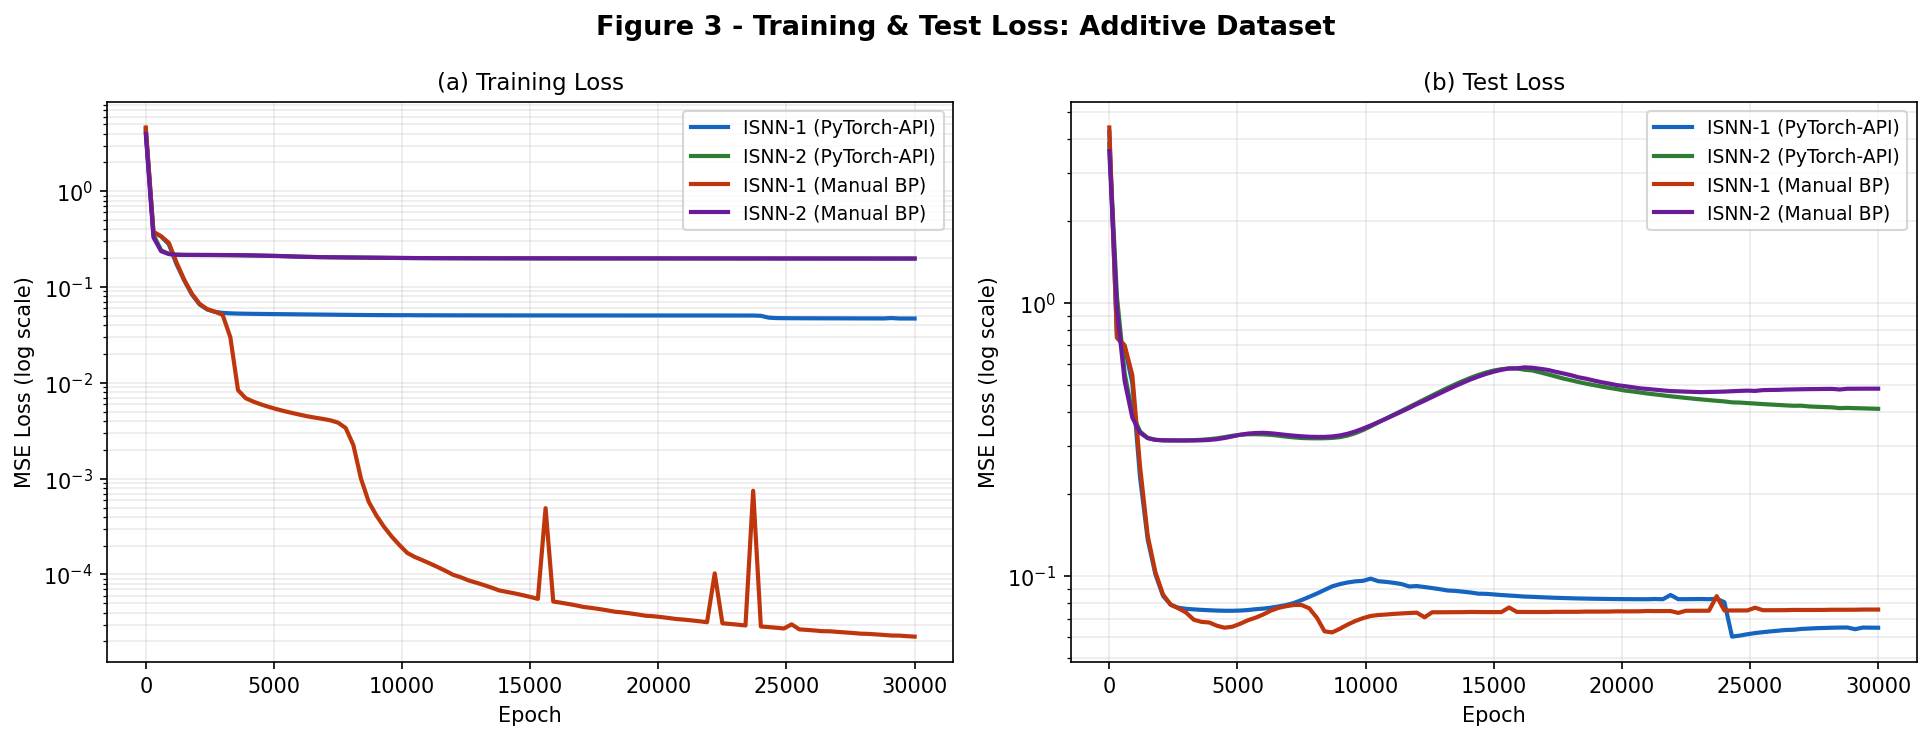

=== FIGURE 4: Behavior - Additive Dataset ===


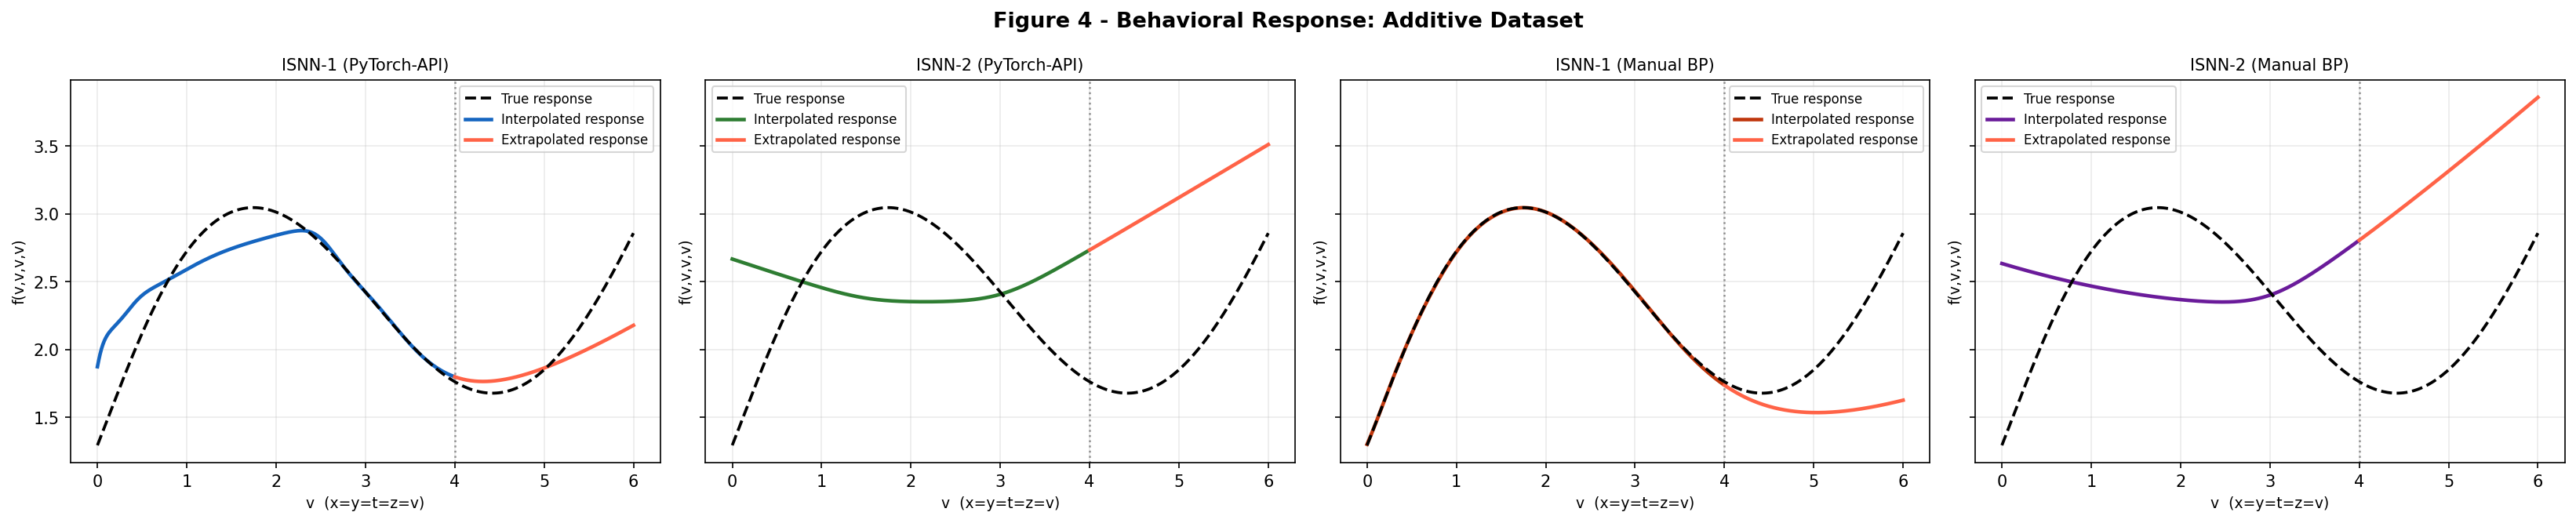

=== FIGURE 5: Loss Curves - Multiplicative Dataset ===


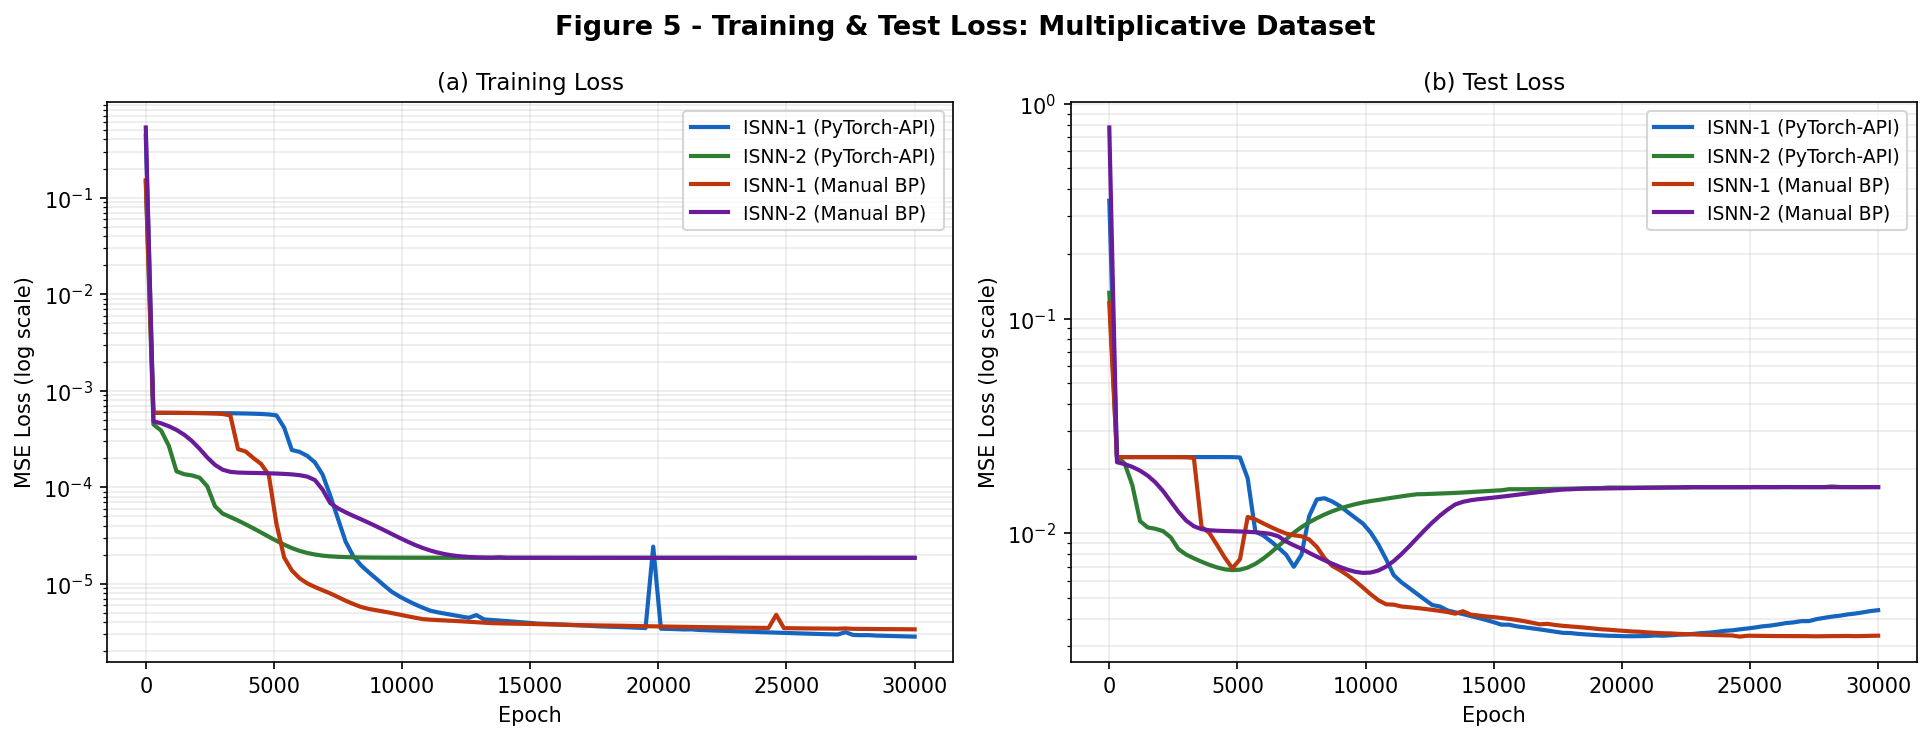

=== FIGURE 6: Behavior - Multiplicative Dataset ===


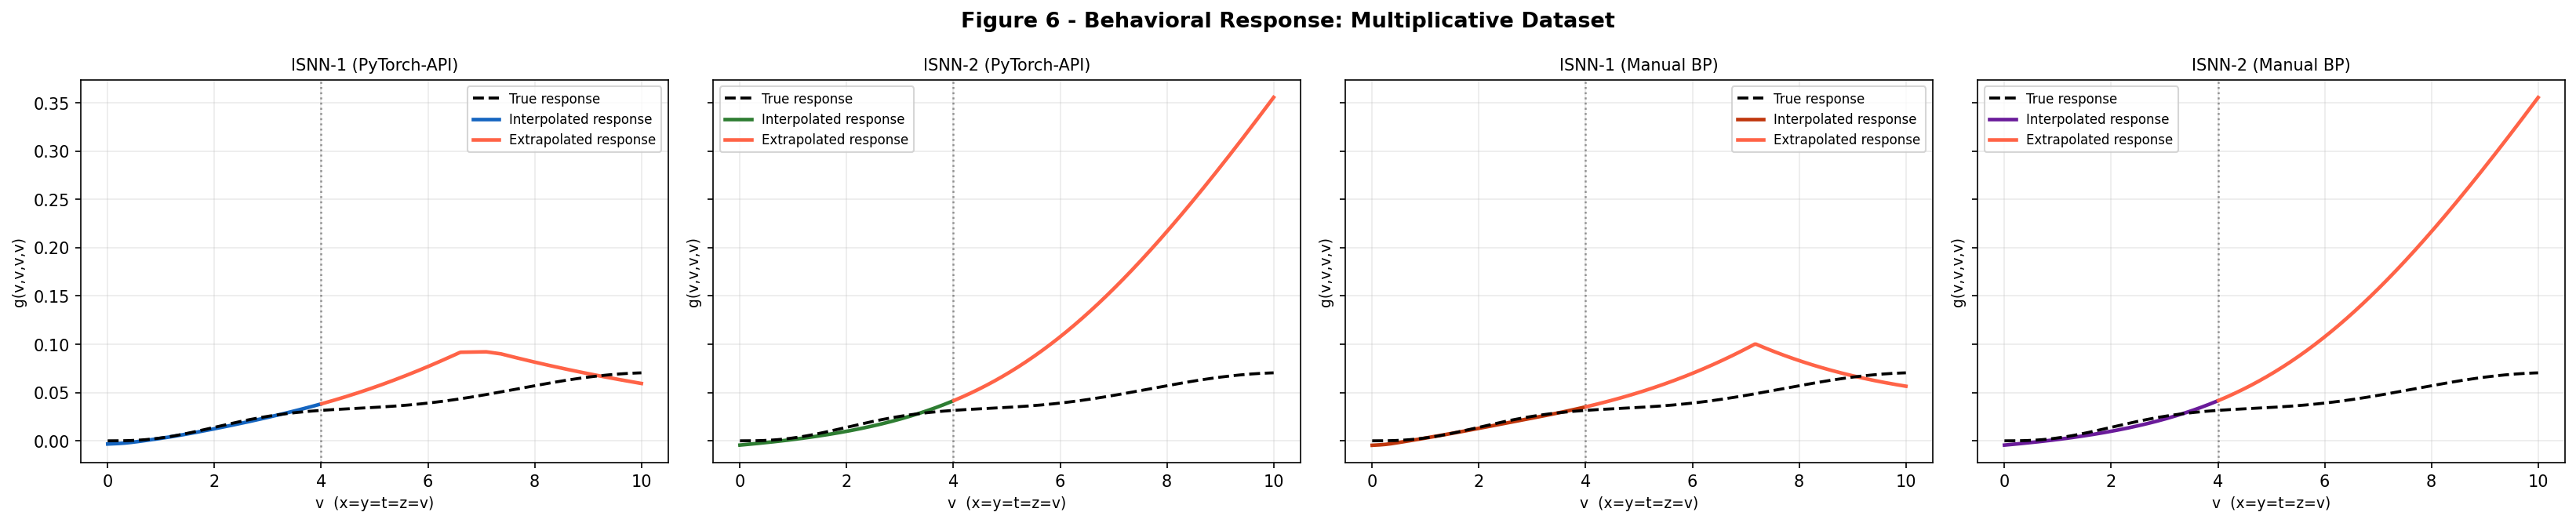

In [2]:
from IPython.display import Image, display

print("=== FIGURE 3: Loss Curves - Additive Dataset ===")
display(Image('outputs/fig3_loss_additive.png'))

print("=== FIGURE 4: Behavior - Additive Dataset ===")
display(Image('outputs/fig4_behavior_additive.png'))

print("=== FIGURE 5: Loss Curves - Multiplicative Dataset ===")
display(Image('outputs/fig5_loss_multiplicative.png'))

print("=== FIGURE 6: Behavior - Multiplicative Dataset ===")
display(Image('outputs/fig6_behavior_multiplicative.png'))